In [1]:
from dotenv import load_dotenv
load_dotenv(".env", override=True)
%load_ext autoreload
%autoreload 2

# Deepagent for Research

`deepagents` 패키지를 사용할 때에는 중요한 것들이 있다.
1. 내장 도구들의 이해가 가능해야 한다.
2. 업무에 특화된 도구를 주입한다.
3. 업무에 특화된 지시를 내린다.
4. 업무에 특화된 서브 에이전트를 준다.

## Task-Specific Tools

### Search Tool
다양한 검색 도구들 중, 여기서는 **Tavily**를 사용해 유사한 URL들을 찾아낸 다음 웹 페이지의 전체 내용을 가져올 것이다.

### Think Tool
이 도구는 에이전트의 의사결정을 감독하기에 유용하다.

In [2]:
from research_agent.tools import tavily_search, think_tool
tools = [tavily_search, think_tool]

## Task-Specific Instructions
https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA

### 1. Think Like The Agent
너의 새로운 동료에게 어떤 지시를 내릴거야?

- Read the question carefully - 사용자가 어떤 특정 정보를 원하는가?
- Start wuth broader search - 처음에는 넓고 포괄적인 쿼리를 사용해
- After each search, pause and assess - 나의 대답이 충분했나? 무언가를 놓치고 있나?
- Execute narrower searches as you gather information - 빈 간격을 채워라

### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
**Hard Limits**를 사용해서 검색 에이전트의 과도한 도구 사용을 예방한다.
- Stop when you can answer confidently - 완벽을 위해 계속 검색하지 마라
- Give it budgets - 간단한 쿼리에는 2-3개의 도구를, 복잡한 쿼리에는 5개까지의 도구를 사용해라.
- Limit - 만약 답을 찾지 못하더라도 5개의 도구를 호출한 뒤에는 반드시 멈춰라.

### 3. Show your thinking
매 검색 도구 호출 후에는 `think_tool`를 사용해 결과를 분석해라.
- 어떤 중요한 정보를 찾았는가?
- 무엇을 놓쳤나?
- 질문을 포괄적으로 하기 위한 충분한 답이 되는가?
- 추가 검색 혹은 나의 견해를 추가해야 하는가?

In [3]:
from datetime import datetime
from utils import show_prompt, format_messages
from research_agent.prompts import (
    RESEARCHER_INSTRUCTIONS,
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,   
)

In [4]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the research tools provided to you to find resources that can help answer the research      │
│  question.                                                                                                      │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Research Tools>                                                                                     │
│  You have access to two specific research tools:                                                                │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Research Tools>                                                                                    │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

### Task-Specific Sub-Agents
컨텍스트 독림을 위해 서브에이전트를 커스텀할 수 있다.
아래는 웹에서 정보를 검색하는 서브 에이전트가 정의돼있다.

In [5]:
# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}

### Putting it all together
#### Instructions
모든 지시를 동시에 볼 수 있다.

In [6]:
# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Combine orchestrator instructions (RESEARCHERINSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 88
    + "\n\n"
    + SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Research Workflow                                                                                            │
│                                                                                                                 │
│  Follow this workflow for all research requests:                                                                │
│                                                                                                                 │
│  1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks                 │
│  2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`       │
│  3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for       │
│  research, never conduct research yourself                                                                      │
│  4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number    │
│  across all findings)                                                                                           │
│  5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines   │
│  below)                                                                                                         │
│  6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and  │
│  structure                                                                                                      │
│                                                                                                                 │
│  ## Research Planning Guidelines                                                                                │
│  - Batch similar research tasks into a single TODO to minimize overhead                                         │
│  - For simple fact-finding questions, use 1 sub-agent                                                           │
│  - For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents                            │
│  - Each sub-agent should research one specific aspect and return findings                                       │
│                                                                                                                 │
│  ## Report Writing Guidelines                                                                                   │
│                                                                                                                 │
│  When writing the final report to `/final_report.md`, follow these structure patterns:                          │
│                                                                                                                 │
│  **For comparisons:**                                                                                           │
│  1. Introduction                                                                                                │
│  2. Overview of topic A                                                                                         │
│  3. Overview of topic B                                                                                         │
│  4. Detailed comparison                                                                                         │
│  5. Conclusion                                                                                                  │
│                                                                                                                 │
│  **For lists/rankings:**                              

### Create the agent
이제 이 요소들을 사용해 딥에이전트를 만든다.

In [7]:
from IPython.display import Image, display
from deepagents import create_deep_agent
from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

# model gpt-5
model = ChatOpenAI(model="gpt-5", temperature=1)

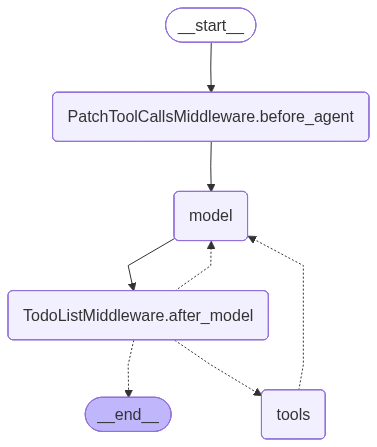

In [8]:
# Create the agent
agent = create_deep_agent(
    model=model,
    tools=tools,
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent],
)

# show the agent
display(Image(agent.get_graph().draw_mermaid_png()))

In [9]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "research Samsung and Nvidia's supply chain relationship",
            }
        ]
    }
)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ research Samsung and Nvidia's supply chain relationship                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save the user's research question to /research_request.md",                                   │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Launch a research sub-agent to investigate Samsung and Nvidia's supply chain relationship     │
│ across foundry, memory (HBM/GDDR), packaging, historical shifts, current status, risks, and outlook; collect    │
│ high-quality sources with URLs",                                                                                │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize sub-agent findings, consolidate and normalize citations (unique URL -> single      │
│ number)",                                                                                                       │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write a comprehensive report to /final_report.md following the summaries/overviews structure  │
│ with clear sections and inline citations",                                                                      │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Verify that the report addresses all aspects of /research_request.md with proper citations    │
│ and structure",                                                                                                 │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_u1KBohrpuvSxY4fM57PFr2Ba                                                                            │
╰─────────────────────────────────────────────────────────

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': "Save the user's research question to /research_request.md", 'status':        │
│ 'in_progress'}, {'content': "Launch a research sub-agent to investigate Samsung and Nvidia's supply chain       │
│ relationship across foundry, memory (HBM/GDDR), packaging, historical shifts, current status, risks, and        │
│ outlook; collect high-quality sources with URLs", 'status': 'in_progress'}, {'content': 'Synthesize sub-agent   │
│ findings, consolidate and normalize citations (unique URL -> single number)', 'status': 'pending'}, {'content': │
│ 'Write a comprehensive report to /final_report.md following the summaries/overviews structure with clear        │
│ sections and inline citations', 'status': 'pending'}, {'content': 'Verify that the report addresses all aspects │
│ of /research_request.md with proper citations and structure', 'status': 'pending'}]                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "/research_request.md",                                                                          │
│   "content": "Research Samsung and Nvidia's supply chain relationship: foundry manufacturing, memory (HBM/GDDR) │
│ supply, advanced packaging, historical shifts, current status (2025), risks, and outlook."                      │
│ }                                                                                                               │
│    ID: call_12OAhW5TLAlYZG75gEyRKemq                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /research_request.md                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "/final_report.md"                                                                               │
│ }                                                                                                               │
│    ID: call_O3IGK6GTKHuwf1IeYHu8VIqJ                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│      1  ## Overview                                                                                             │
│      2  Samsung and Nvidia have a multifaceted supply chain relationship centered on three domains: (1) logic   │
│ foundry manufacturing for GPUs/accelerators, (2) memory supply for both gaming (GDDR6/6X) and datacenter        │
│ accelerators (HBM families), and (3) advanced packaging for high‑bandwidth, multi‑die integration.              │
│ Historically, Nvidia used both Samsung Foundry and TSMC for different product lines and generations; since      │
│ 2022–2025, Nvidia’s flagship GPUs/accelerators have been closely aligned with TSMC’s leading-edge nodes and     │
│ CoWoS packaging, while Samsung plays a significant role in GDDR and, by late 2025, becomes a qualified HBM3E    │
│ supplier to Nvidia alongside SK hynix and Micron [1][2][3][4][5][6][8][9][13][14][15][16][17].                  │
│      3                                                                                                          │
│      4  ## Foundry manufacturing (Samsung vs. TSMC)                                                             │
│      5  - Ampere (GeForce RTX 30 series, 2020): Nvidia’s GeForce Ampere gaming GPUs were produced on Samsung’s  │
│ custom 8nm “8N” process, reflecting capacity/pricing dynamics of the period and a divergence from               │
│ contemporaneous Nvidia data center parts made at TSMC [10][11][12].                                             │
│      6  - Ada Lovelace (GeForce RTX 40 series, 2022): Nvidia returned to TSMC on a custom 4N process for Ada,   │
│ confirmed in Nvidia’s architecture whitepaper and widely reported by independent outlets [1][13][14].           │
│      7  - Hopper H100 (datacenter, 2022): Nvidia’s H100 is documented in Nvidia’s own materials and commentary  │
│ as fabricated on a TSMC 4N‑class process and paired with advanced packaging to integrate HBM3 stacks [2][3].    │
│      8  - Current posture (2025): Public disclosures and industry reporting continue to associate Nvidia’s      │
│ leading GPUs/accelerators (Ada/Hopper and successor Blackwell family) with TSMC’s advanced nodes and packaging, │
│ with no confirmed 2025 production wins for Samsung Foundry on those flagships [1][2][3][5][6].                  │
│      9                                                                                                          │
│     10  ## Memory supply (GDDR and HBM)                                                                         │
│     11  - GDDR6/6X for gaming: Samsung is a long‑standing supplier of GDDR6 used across multiple Nvidia GeForce │
│ models, alongside Micron (including Micron’s GDDR6X on select SKUs). Board and teardown evidence shows Samsung  │
│ GDDR6 present on Nvidia’s reference and AIB partner cards, and Samsung continues to publish high‑speed GDDR6    │
│ capabilities (up to 24 Gbps) for GPU applications [15][16][17].                                                 │
│     12  - HBM for accelerators:                                                                                 │
│     13    - Supply dynamics through 2024–2025: SK hynix was the dominant HBM3 supplier and reported HBM         │
│ capacity was almost sold out for 2025, underscoring severe supply tightness as AI accelerator demand surged     │
│ [4]. TSMC’s advanced packaging (CoWoS) also acted as a system‑level bottleneck for Nvidia platforms during      │
│ 2023–2024 [5][6][7].                                                                                            │
│     14    - Nvidia supplier diversification in 2024–2025: Micron joined Nvidia’s HBM3E supplier set during      │
│ 2024–2025 per broad industry coverage, while late‑2025 reporting indicates Samsung secured Nvidia qualification │
│ for 12‑high HBM3E, making Samsung a third supplier afte

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save the user's research question to /research_request.md",                                   │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Launch a research sub-agent to investigate Samsung and Nvidia's supply chain relationship     │
│ across foundry, memory (HBM/GDDR), packaging, historical shifts, current status, risks, and outlook; collect    │
│ high-quality sources with URLs",                                                                                │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize sub-agent findings, consolidate and normalize citations (unique URL -> single      │
│ number)",                                                                                                       │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write a comprehensive report to /final_report.md following the summaries/overviews structure  │
│ with clear sections and inline citations",                                                                      │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Verify that the report addresses all aspects of /research_request.md with proper citations    │
│ and structure",                                                                                                 │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_zUhxw1rCCdJ0Bffnl94hAFa5                                                                            │
╰─────────────────────────────────────────────────────────

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': "Save the user's research question to /research_request.md", 'status':        │
│ 'completed'}, {'content': "Launch a research sub-agent to investigate Samsung and Nvidia's supply chain         │
│ relationship across foundry, memory (HBM/GDDR), packaging, historical shifts, current status, risks, and        │
│ outlook; collect high-quality sources with URLs", 'status': 'completed'}, {'content': 'Synthesize sub-agent     │
│ findings, consolidate and normalize citations (unique URL -> single number)', 'status': 'completed'},           │
│ {'content': 'Write a comprehensive report to /final_report.md following the summaries/overviews structure with  │
│ clear sections and inline citations', 'status': 'completed'}, {'content': 'Verify that the report addresses all │
│ aspects of /research_request.md with proper citations and structure', 'status': 'completed'}]                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Completed. A full, source-cited report is saved to /final_report.md.                                            │
│                                                                                                                 │
│ Quick summary:                                                                                                  │
│ - Foundry                                                                                                       │
│   - Nvidia used Samsung Foundry’s custom 8nm (8N) for GeForce RTX 30 (Ampere) in 2020.                          │
│   - Nvidia returned to TSMC for Ada Lovelace (GeForce RTX 40) on custom 4N and Hopper H100 on TSMC 4N-class.    │
│   - As of 2025, there are no confirmed Samsung Foundry wins for Nvidia’s flagship accelerators; Blackwell-era   │
│ parts remain aligned with TSMC.                                                                                 │
│                                                                                                                 │
│ - Memory                                                                                                        │
│   - GDDR: Samsung remains a major GDDR6 supplier across Nvidia’s ecosystem, alongside Micron (notably GDDR6X on │
│ select SKUs).                                                                                                   │
│   - HBM: SK hynix is the anchor HBM3 supplier and reported HBM capacity “almost sold out for 2025.” Micron      │
│ joined with HBM3E in 2024–2025. Reports indicate Samsung secured Nvidia qualification for 12-high HBM3E in late │
│ 2025, becoming Nvidia’s third HBM supplier.                                                                     │
│                                                                                                                 │
│ - Advanced packaging                                                                                            │
│   - Nvidia’s leading accelerators rely on TSMC CoWoS/3DFabric for integrating logic and HBM; this has been a    │
│ key supply bottleneck.                                                                                          │
│   - No public confirmation that Nvidia uses Samsung’s advanced packaging (I‑Cube/X‑Cube/SAINT) for flagship     │
│ accelerators as of 2025.                                                                                        │
│                                                                                                                 │
│ - Historical shifts                                                                                             │
│   - 2020: Samsung 8N for GeForce Ampere (RTX 30) amid capacity/pricing dynamics.                                │
│   - 2022: Return to TSMC 4N for Ada; Hopper also on TSMC 4N-class with CoWoS.                                   │
│   - 2023–2024: TSMC CoWoS capacity constraints; HBM tightness intensifies.                                      │
│   - 2025: Supplier diversification accelerates; Samsung HBM3E qualification reported.                           │
│                                                                                                                 │
│ - Risks and outlook                                                                                             │
│   - Risks: Ongoing HBM and CoWoS capacity bottlenecks; supplier concentration on TSMC; yield/stack-height       │
│ execution for HBM3E/HBM4; export-control-driven product mix changes.                                            │
│   - Outlook: With Samsung qualified for HBM3E and Micron ramping, Nvidia is positioned to diversify HBM supply  │
│ beyond SK hynix starting 2025–2026. TSMC continues expanding CoWoS capacity; any Samsung wins in packaging or   │
│ leading-edge foundry would be strategically significant